# 🐟 Training Model v5 — AquaAgent Random Forest Classifier
## Comprehensive Analysis untuk Skripsi / Jurnal Ilmiah

### Dataset: `Data_Model_IoTMLCQ_2024.xlsx`
### Pelabelan berdasarkan Jurnal Ilmiah (Figure 1):
| Parameter | Rentang Optimal | Sumber |
|-----------|----------------|--------|
| **Suhu** | 25 – 32 °C | El-Sayed 1999; FAO 2023 |
| **pH** | 7.0 – 8.0 | Lemos et al. 2018; Mengistu et al. 2020 |
| **Dissolved Oxygen** | > 5.0 mg/L | Pedrazzani et al. 2020; Tran-Duy et al. 2012 |
| **Kekeruhan** | ≤ 25 NTU | Standard Aquaculture |

### Daftar Isi Analisis:
1. Import Library & Setup
2. Load & Eksplorasi Data (EDA)
3. Statistik Deskriptif
4. Distribusi Fitur (Histogram & KDE)
5. Boxplot per Health Status
6. Correlation Heatmap
7. Pairplot
8. Pelabelan Ilmiah (Scientific Labeling)
9. Feature Engineering
10. Train-Test Split
11. **Training & Perbandingan Model** (RF, ExtraTrees, HistGradientBoosting, SVM, KNN, Decision Tree, Logistic Regression)
12. **Confusion Matrix** (Model Terbaik)
13. **Classification Report** (Tabel Metrik)
14. **Feature Importance**
15. **Cross-Validation (5-Fold Stratified)**
16. **ROC Curve & AUC**
17. **Precision-Recall Curve**
18. **Learning Curve**
19. **Ringkasan Perbandingan Model** (Tabel & Bar Chart)
20. **Save Model**
21. **Sample Prediction & Interpretasi**

---
## 1. Import Library & Setup

In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingClassifier, 
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# Style setup untuk jurnal
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.figsize': (10, 6),
    'savefig.bbox': 'tight'
})

COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#FFC107', '#9C27B0', '#00BCD4', '#E91E63']
print('✅ Library imported successfully')

✅ Library imported successfully


---
## 2. Load & Eksplorasi Data (EDA)

In [15]:
# Load Dataset
df_excel = pd.read_excel('Data_Model_IoTMLCQ_2024.xlsx')

# Identifikasi kolom suhu (handle encoding karakter khusus)
temp_col = [c for c in df_excel.columns if 'Temperature (' in c][0]

# Buat dataframe bersih dengan kolom yang relevan
df = pd.DataFrame({
    'TEMP': pd.to_numeric(df_excel[temp_col], errors='coerce'),
    'DO': pd.to_numeric(df_excel['Dissolved Oxygen (mg/L)'], errors='coerce'),
    'PH': pd.to_numeric(df_excel['pH'], errors='coerce'),
    'TURBIDITY': pd.to_numeric(df_excel['Turbidity (NTU)'], errors='coerce'),
    'hour': pd.to_numeric(df_excel['hour'], errors='coerce'),
    'Health_Status': df_excel['Health Status']
}).dropna()

print(f'📊 Dataset Shape: {df.shape}')
print(f'📊 Total Sampel: {len(df)}')
print(f'📊 Jumlah Fitur: {df.shape[1] - 1}')  # minus label
print(f'\n📊 Missing Values:')
print(df.isnull().sum())
print(f'\n📊 Data Types:')
print(df.dtypes)
df.head(10)

📊 Dataset Shape: (4383, 6)
📊 Total Sampel: 4383
📊 Jumlah Fitur: 5

📊 Missing Values:
TEMP             0
DO               0
PH               0
TURBIDITY        0
hour             0
Health_Status    0
dtype: int64

📊 Data Types:
TEMP             float64
DO               float64
PH               float64
TURBIDITY        float64
hour             float64
Health_Status        str
dtype: object


,TEMP,DO,PH,TURBIDITY,hour,Health_Status
0,27.47,6.34,7.98,3.3,0.000000,Stable
1,27.47,6.34,7.98,3.3,1.000000,Stable
2,27.47,6.34,7.98,3.3,2.000000,Stable
3,27.47,6.34,7.98,3.3,3.000000,Stable
4,27.47,6.34,7.98,3.3,4.000000,Stable
5,27.47,6.34,7.98,3.3,5.000000,Stable
6,27.47,6.34,7.98,3.3,4.736842,Stable
7,27.47,6.34,7.98,3.3,4.473684,Stable
8,27.47,6.34,7.98,3.3,4.210526,Stable
9,27.47,6.34,7.98,3.3,3.947368,Stable


---
## 3. Statistik Deskriptif

In [16]:
# Statistik Deskriptif lengkap
desc = df[['TEMP', 'DO', 'PH', 'TURBIDITY', 'hour']].describe()
desc.loc['range'] = desc.loc['max'] - desc.loc['min']
desc.loc['IQR'] = desc.loc['75%'] - desc.loc['25%']
desc.loc['skewness'] = df[['TEMP', 'DO', 'PH', 'TURBIDITY', 'hour']].skew()
desc.loc['kurtosis'] = df[['TEMP', 'DO', 'PH', 'TURBIDITY', 'hour']].kurtosis()

print('📊 Statistik Deskriptif Lengkap:')
desc.round(4)

📊 Statistik Deskriptif Lengkap:


,TEMP,DO,PH,TURBIDITY,hour
count,4383.0000,4383.0000,4383.0000,4383.0000,4383.0000
mean,27.3449,6.9297,7.8299,3.3056,2.5599
std,0.6197,0.6317,0.2144,0.4310,1.4904
min,26.5000,6.3400,7.3400,2.7900,0.0000
25%,26.6000,6.3900,7.8800,2.7900,1.3158
50%,27.4500,6.6800,7.8900,3.3000,2.6316
75%,27.7000,7.7200,7.9700,3.7100,3.9474
max,28.3500,7.8900,7.9800,3.9800,5.0000
range,1.8500,1.5500,0.6400,1.1900,5.0000
IQR,1.1000,1.3300,0.0900,0.9200,2.6316


---
## 4. Distribusi Health Status (Label Asli Dataset)

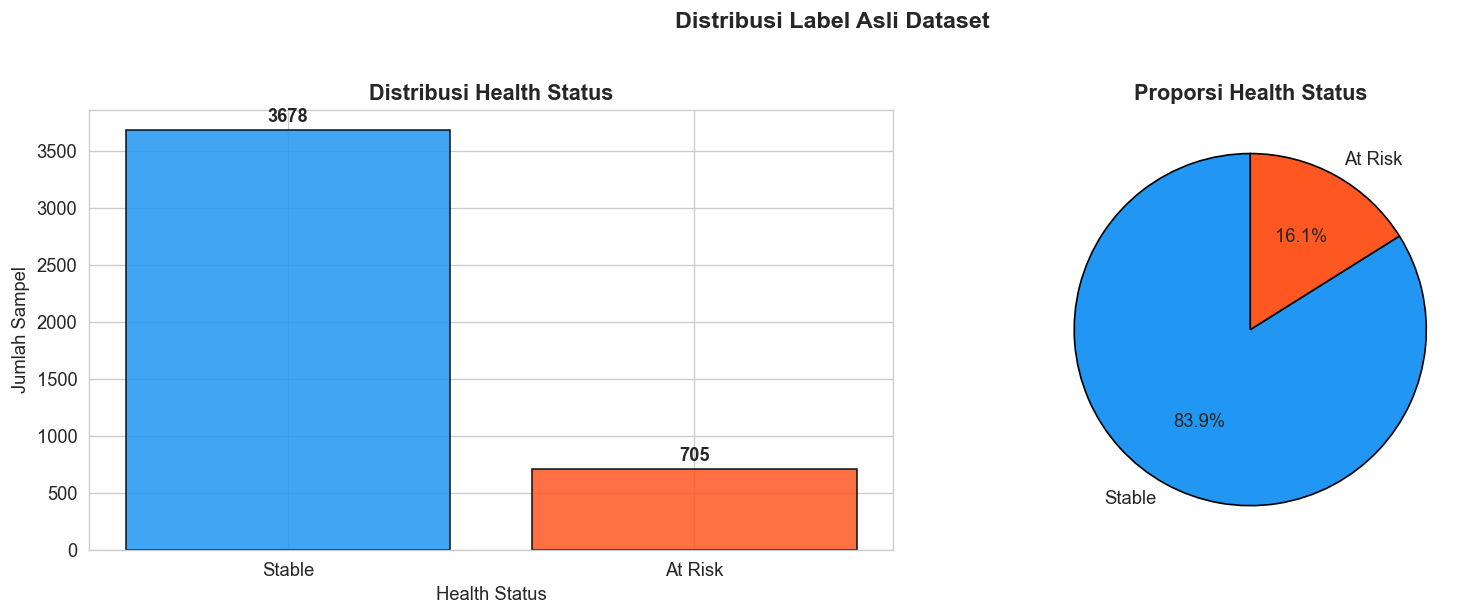

Health_Status
Stable     3678
At Risk     705
Name: count, dtype: int64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
status_counts = df['Health_Status'].value_counts()
bars = axes[0].bar(status_counts.index, status_counts.values, color=COLORS[:len(status_counts)], edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Health Status', fontweight='bold')
axes[0].set_xlabel('Health Status')
axes[0].set_ylabel('Jumlah Sampel')
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 5), textcoords='offset points', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=COLORS[:len(status_counts)], startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proporsi Health Status', fontweight='bold')

plt.suptitle('Distribusi Label Asli Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(status_counts)

---
## 5. Distribusi Fitur Sensor (Histogram + KDE)

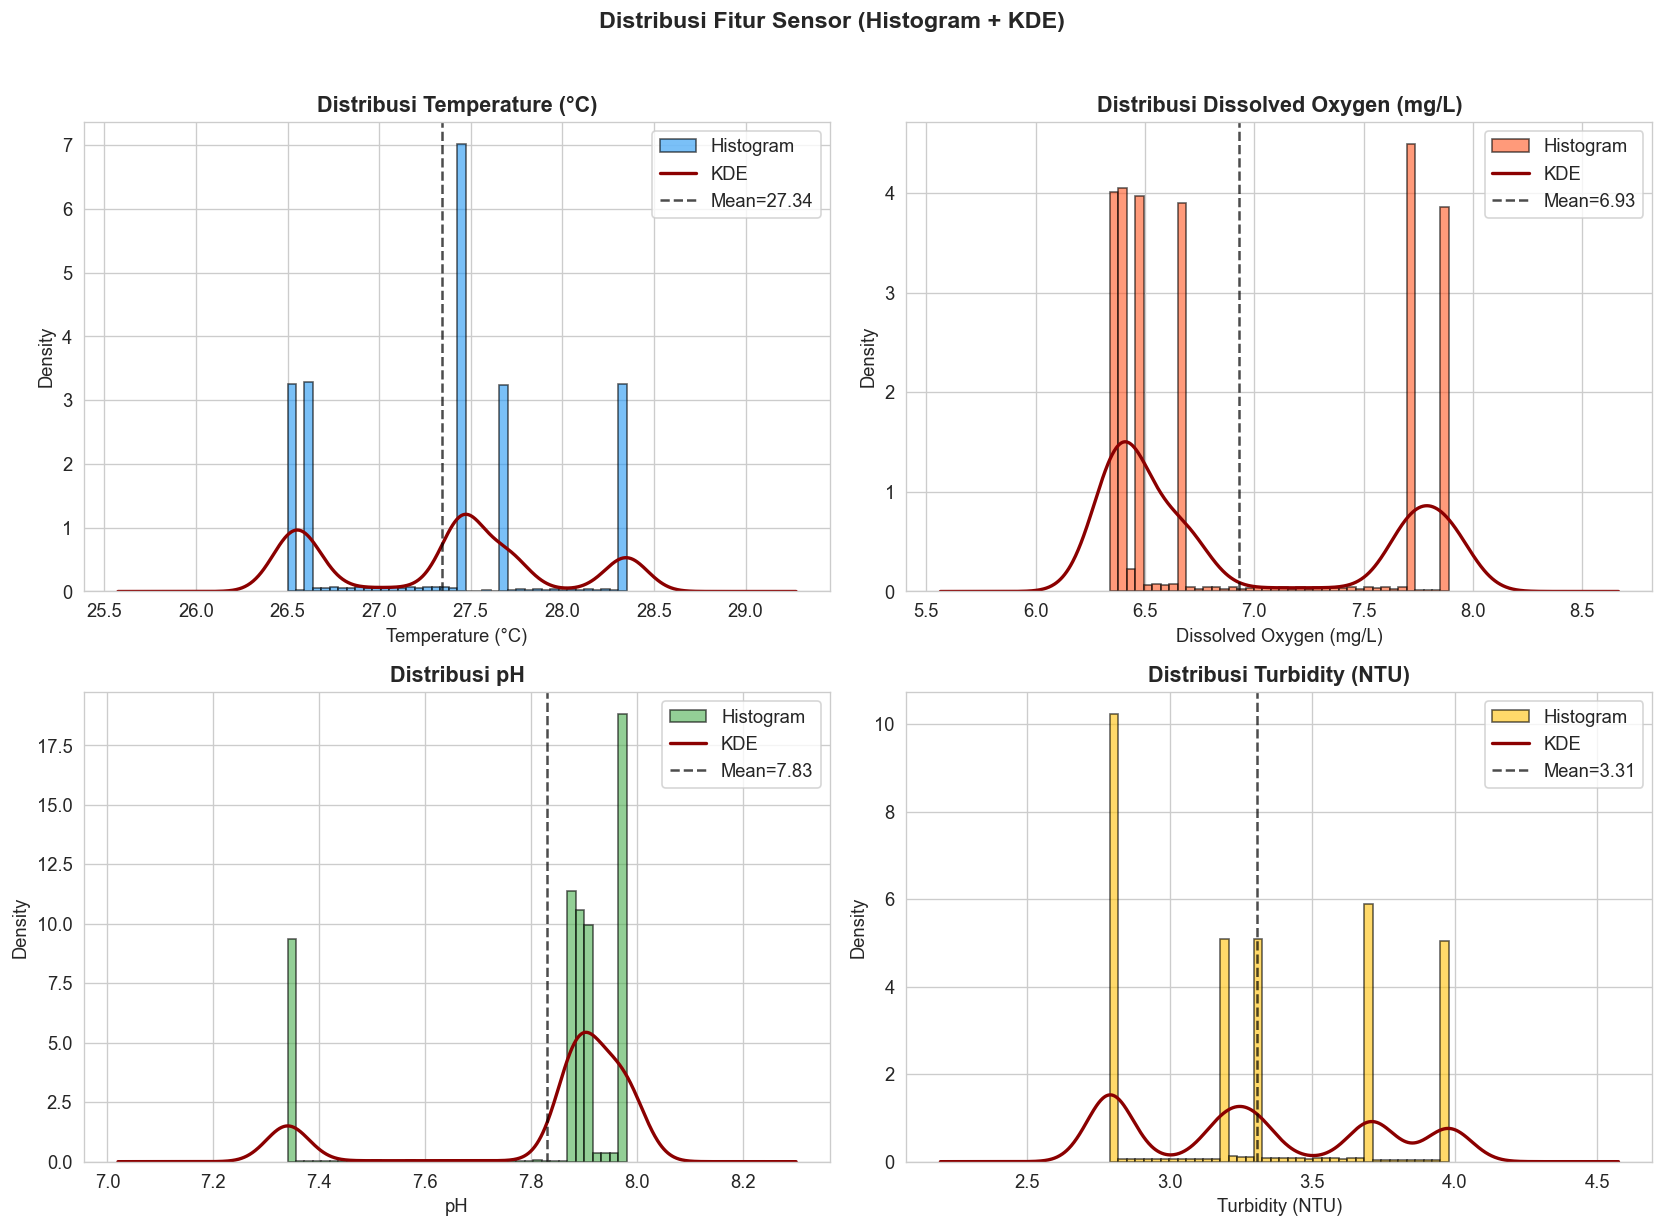

In [18]:
sensor_cols = ['TEMP', 'DO', 'PH', 'TURBIDITY']
sensor_labels = ['Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(sensor_cols, sensor_labels)):
    ax = axes[i]
    ax.hist(df[col], bins=40, color=COLORS[i], alpha=0.6, edgecolor='black', density=True, label='Histogram')
    df[col].plot.kde(ax=ax, color='darkred', linewidth=2, label='KDE')
    ax.set_title(f'Distribusi {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()
    ax.axvline(df[col].mean(), color='black', linestyle='--', alpha=0.7, label=f'Mean={df[col].mean():.2f}')
    ax.legend()

plt.suptitle('Distribusi Fitur Sensor (Histogram + KDE)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Boxplot Fitur per Health Status

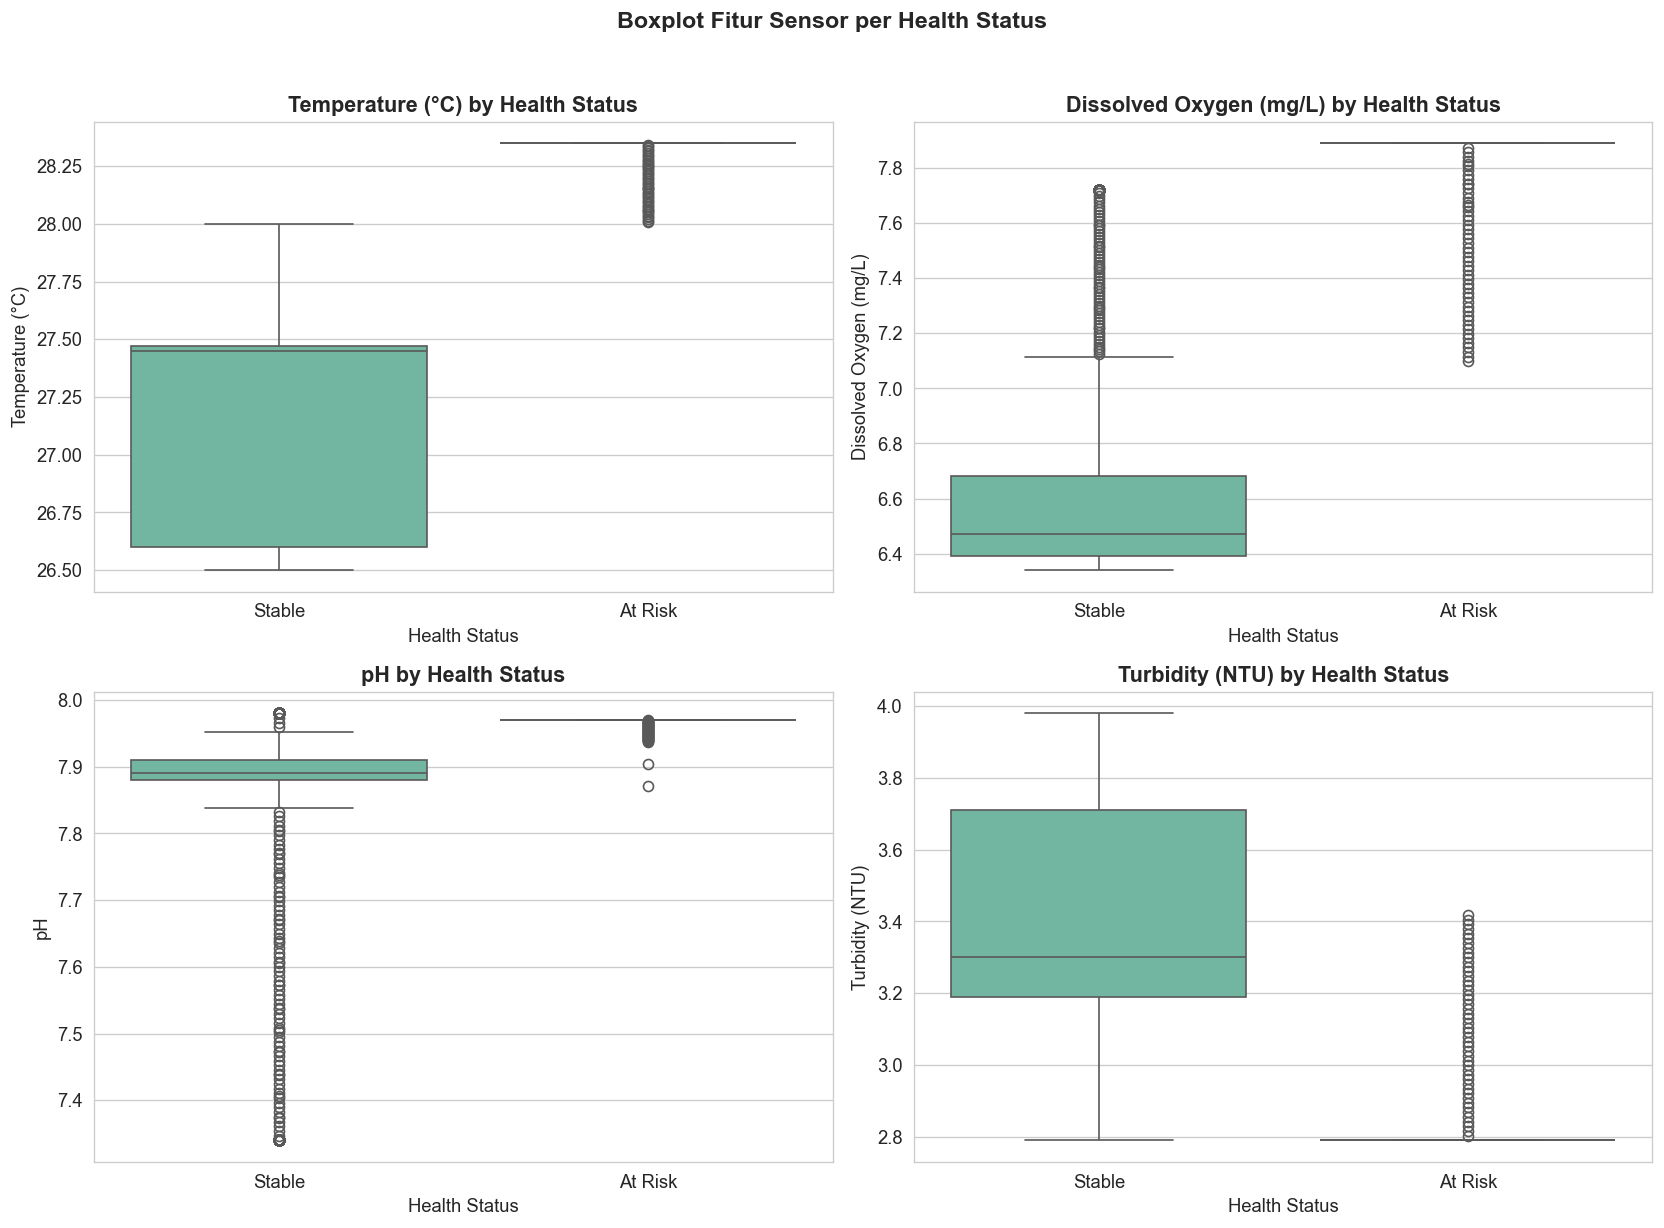

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(sensor_cols, sensor_labels)):
    sns.boxplot(data=df, x='Health_Status', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{label} by Health Status', fontweight='bold')
    axes[i].set_xlabel('Health Status')
    axes[i].set_ylabel(label)

plt.suptitle('Boxplot Fitur Sensor per Health Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Correlation Heatmap

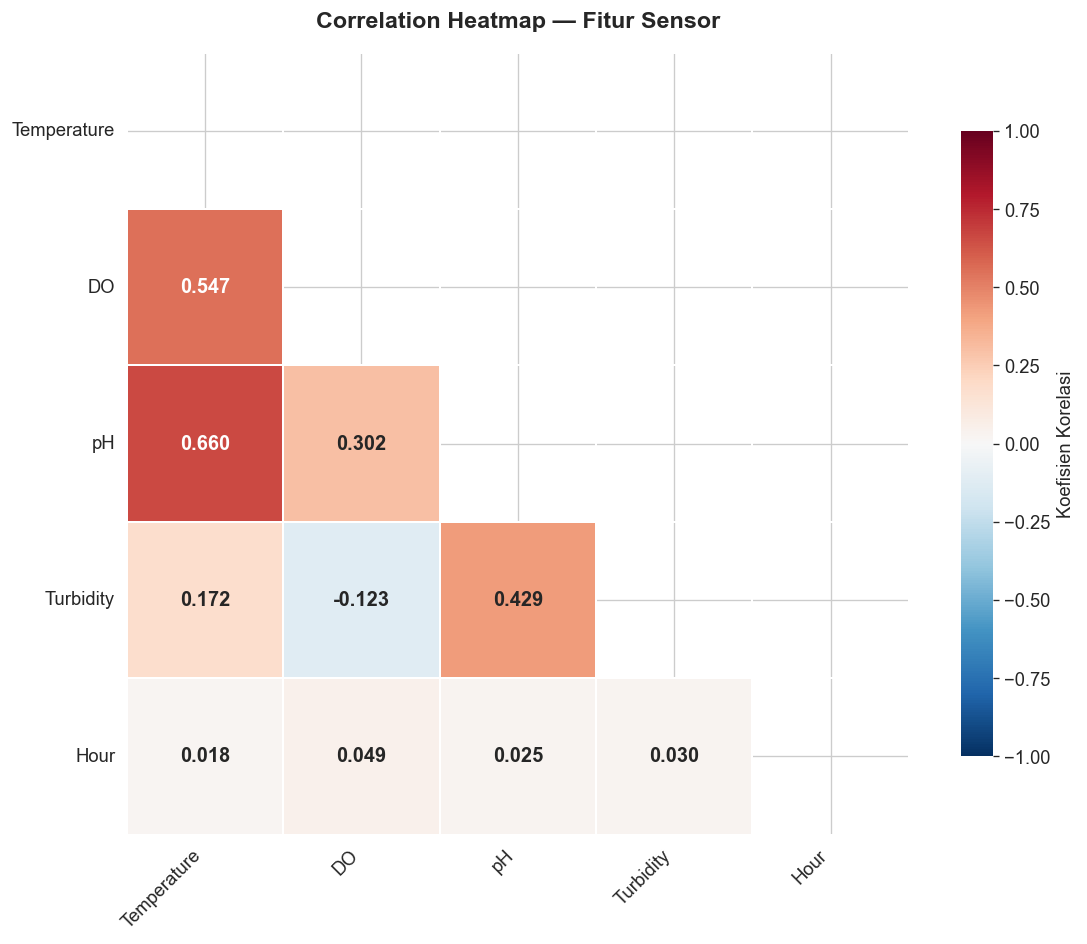

📊 Correlation Matrix:
             TEMP      DO      PH  TURBIDITY    hour
TEMP       1.0000  0.5470  0.6602     0.1720  0.0180
DO         0.5470  1.0000  0.3022    -0.1227  0.0490
PH         0.6602  0.3022  1.0000     0.4294  0.0253
TURBIDITY  0.1720 -0.1227  0.4294     1.0000  0.0296
hour       0.0180  0.0490  0.0253     0.0296  1.0000


In [20]:
corr = df[['TEMP', 'DO', 'PH', 'TURBIDITY', 'hour']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
            annot_kws={'size': 12, 'fontweight': 'bold'},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap — Fitur Sensor', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(['Temperature', 'DO', 'pH', 'Turbidity', 'Hour'], rotation=45, ha='right')
ax.set_yticklabels(['Temperature', 'DO', 'pH', 'Turbidity', 'Hour'], rotation=0)
plt.tight_layout()
plt.show()

print('📊 Correlation Matrix:')
print(corr.round(4).to_string())

---
## 8. Pairplot (Scatter Matrix)

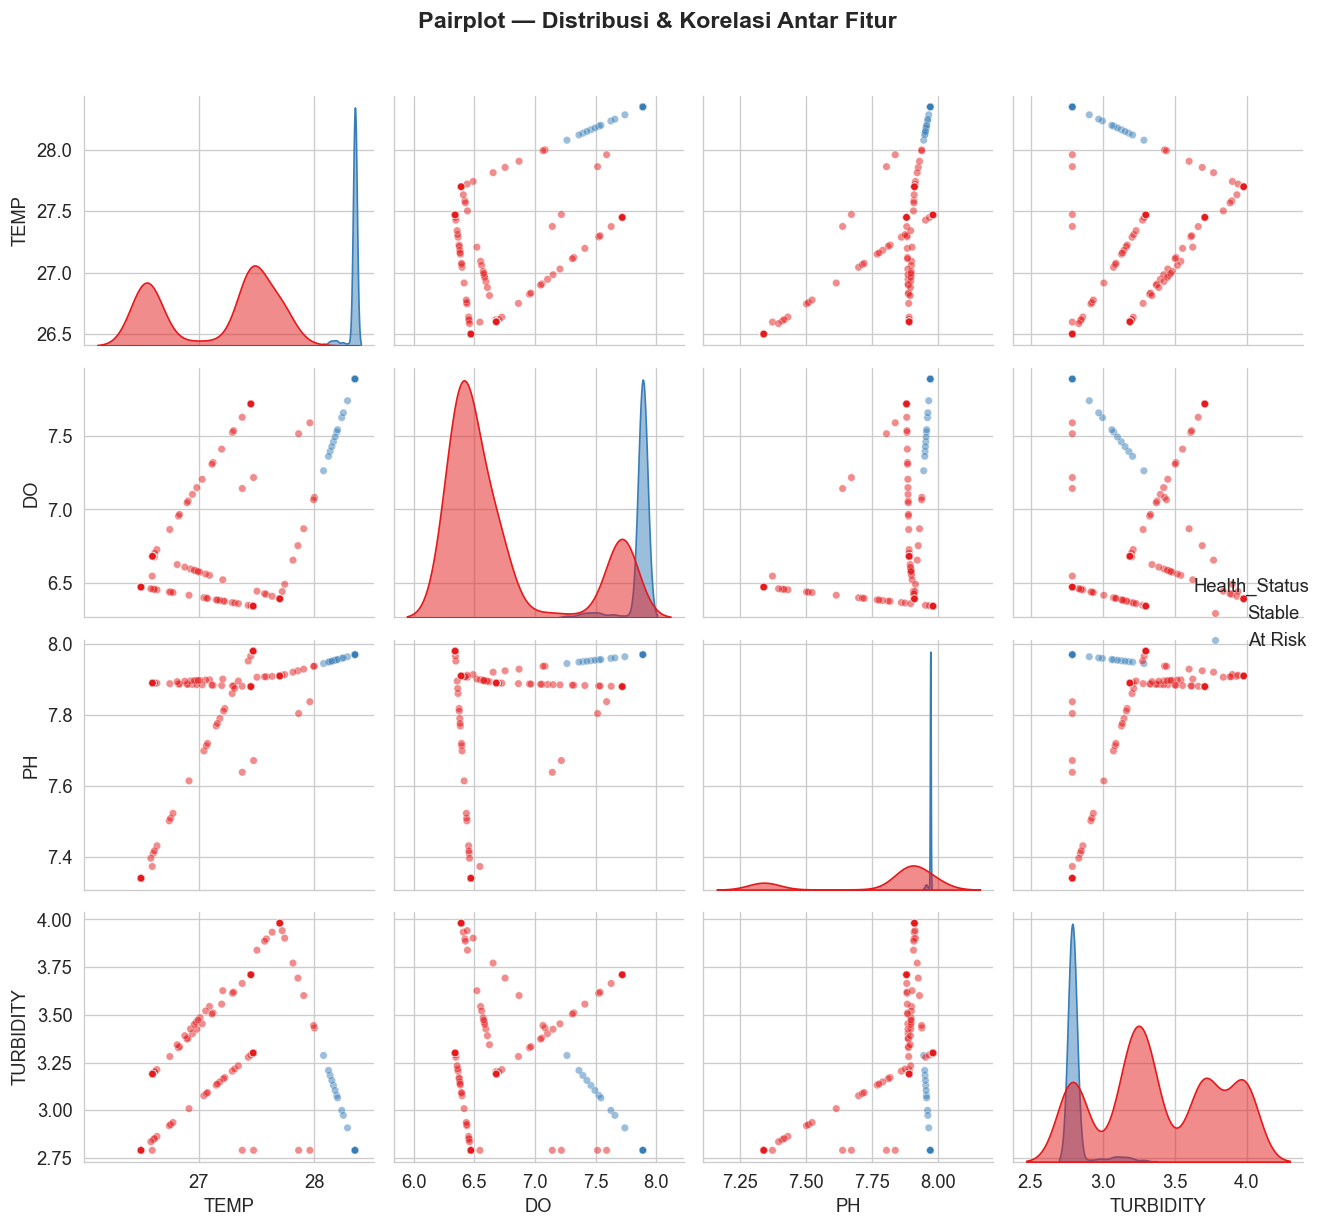

In [21]:
# Pairplot dengan subsample untuk efisiensi
df_sample = df.sample(n=min(1000, len(df)), random_state=42)

g = sns.pairplot(df_sample[['TEMP', 'DO', 'PH', 'TURBIDITY', 'Health_Status']], 
                 hue='Health_Status', palette='Set1', diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kws={'fill': True, 'alpha': 0.5})
g.figure.suptitle('Pairplot — Distribusi & Korelasi Antar Fitur', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Pelabelan Ilmiah (Scientific Labeling)

Berdasarkan referensi jurnal ilmiah:
- **Normal (0)**: SEMUA parameter dalam rentang optimal
- **Tidak Normal (1)**: SALAH SATU parameter di luar rentang optimal

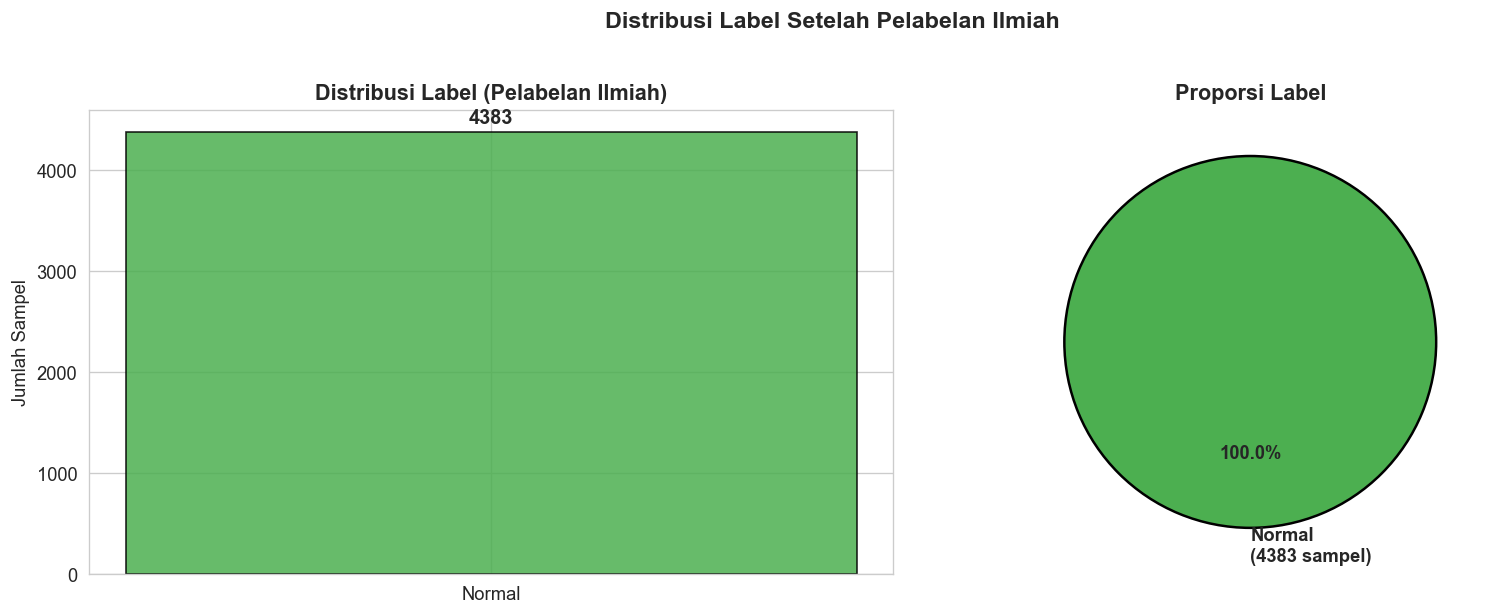


📊 Label Distribution:
   Normal (0)       : 4383 sampel (100.0%)
   Tidak Normal (1) : 0 sampel (0.0%)


In [22]:
# Fungsi Pelabelan Berdasarkan Jurnal Ilmiah
def label_water_quality(row):
    temp_ok = 25.0 <= row['TEMP'] <= 32.0
    ph_ok = 7.0 <= row['PH'] <= 8.0
    do_ok = row['DO'] > 5.0
    turb_ok = row['TURBIDITY'] <= 25.0
    
    if temp_ok and ph_ok and do_ok and turb_ok:
        return 0  # Normal
    else:
        return 1  # Tidak Normal

df['label'] = df.apply(label_water_quality, axis=1)

# Distribusi label baru
label_counts = df['label'].value_counts().sort_index()
label_names = {0: 'Normal', 1: 'Tidak Normal'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar([label_names[i] for i in label_counts.index], label_counts.values,
                   color=['#4CAF50', '#F44336'], edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Label (Pelabelan Ilmiah)', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 5), textcoords='offset points', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(label_counts.values, labels=[f'{label_names[i]}\n({v} sampel)' for i, v in zip(label_counts.index, label_counts.values)],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Label', fontweight='bold')

plt.suptitle('Distribusi Label Setelah Pelabelan Ilmiah', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📊 Label Distribution:')
print(f'   Normal (0)       : {label_counts.get(0, 0)} sampel ({label_counts.get(0, 0)/len(df)*100:.1f}%)')
print(f'   Tidak Normal (1) : {label_counts.get(1, 0)} sampel ({label_counts.get(1, 0)/len(df)*100:.1f}%)')

---
## 10. Feature Engineering

Fitur tambahan non-linear dan cyclical encoding untuk meningkatkan performa model.

In [23]:
# Feature Engineering v5
df['PH_dist_7'] = np.abs(df['PH'] - 7.0)
df['TEMP_DO_ratio'] = df['DO'] / (df['TEMP'] + 1.0)
df['TURB_DO_ratio'] = df['TURBIDITY'] / (df['DO'] + 0.1)
df['TEMP_PH_ratio'] = df['TEMP'] / (df['PH'] + 0.1)

# Cyclical hour encoding (menangkap siklus 24 jam)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

features_engineered = [
    'TEMP', 'DO', 'PH', 'TURBIDITY', 'hour',
    'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio',
    'hour_sin', 'hour_cos'
]

print('✅ Feature Engineering Completed')
print(f'\n📊 Total Fitur: {len(features_engineered)}')
print(f'📊 Fitur: {features_engineered}')
print(f'\n📊 Contoh Data Setelah Feature Engineering:')
df[features_engineered + ['label']].head(5)

✅ Feature Engineering Completed

📊 Total Fitur: 11
📊 Fitur: ['TEMP', 'DO', 'PH', 'TURBIDITY', 'hour', 'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio', 'hour_sin', 'hour_cos']

📊 Contoh Data Setelah Feature Engineering:


,TEMP,DO,PH,TURBIDITY,hour,PH_dist_7,TEMP_DO_ratio,TURB_DO_ratio,TEMP_PH_ratio,hour_sin,hour_cos,label
0,27.47,6.34,7.98,3.3,0.0,0.98,0.222691,0.512422,3.399752,0.000000,1.000000,0
1,27.47,6.34,7.98,3.3,1.0,0.98,0.222691,0.512422,3.399752,0.258819,0.965926,0
2,27.47,6.34,7.98,3.3,2.0,0.98,0.222691,0.512422,3.399752,0.500000,0.866025,0
3,27.47,6.34,7.98,3.3,3.0,0.98,0.222691,0.512422,3.399752,0.707107,0.707107,0
4,27.47,6.34,7.98,3.3,4.0,0.98,0.222691,0.512422,3.399752,0.866025,0.500000,0


---
## 10b. Correlation Heatmap (Setelah Feature Engineering)

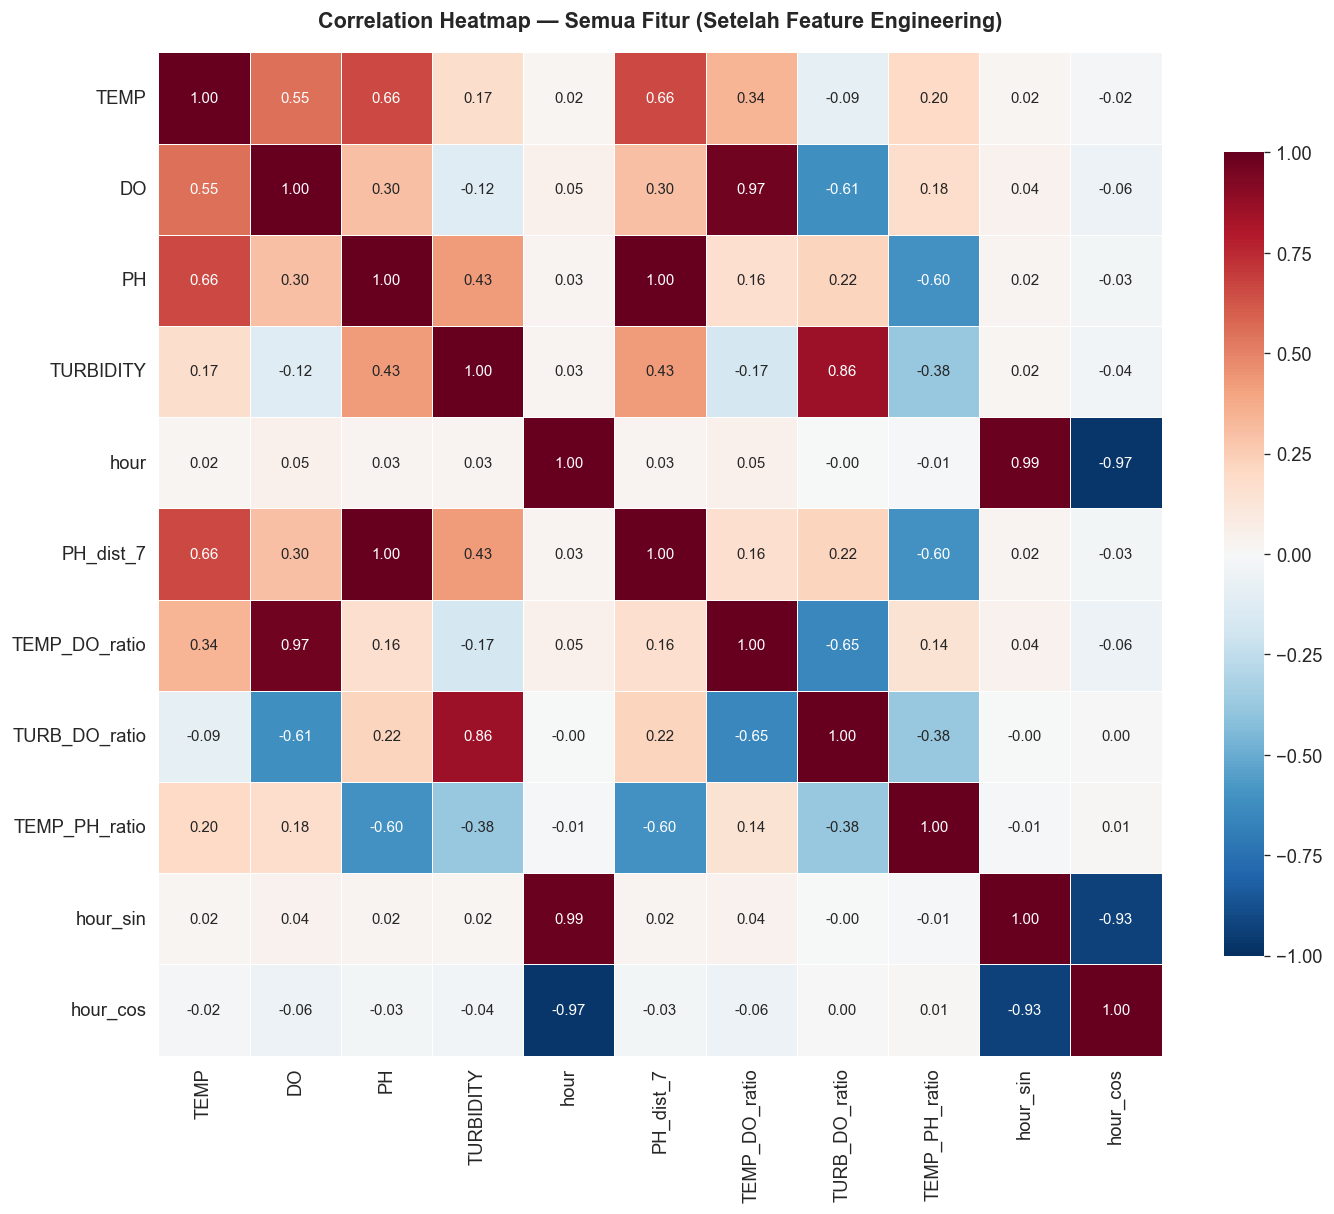

In [24]:
corr_eng = df[features_engineered].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_eng, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap — Semua Fitur (Setelah Feature Engineering)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 11. Train-Test Split

In [25]:
X = df[features_engineered]
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'📊 Training Data : {len(X_train)} sampel ({len(X_train)/len(X)*100:.1f}%)')
print(f'📊 Testing Data  : {len(X_test)} sampel ({len(X_test)/len(X)*100:.1f}%)')
print(f'\n📊 Distribusi Label pada Training Set:')
print(y_train.value_counts().to_string())
print(f'\n📊 Distribusi Label pada Testing Set:')
print(y_test.value_counts().to_string())

📊 Training Data : 3506 sampel (80.0%)
📊 Testing Data  : 877 sampel (20.0%)

📊 Distribusi Label pada Training Set:
label
0    3506

📊 Distribusi Label pada Testing Set:
label
0    877


---
## 12. Training & Perbandingan Model

Membandingkan **7 algoritma Machine Learning** untuk menemukan model terbaik.

In [26]:
# Definisi 7 Model ML
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=25, random_state=42, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300, max_depth=25, random_state=42, n_jobs=-1
    ),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=15, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=15, random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'SVM (RBF Kernel)': SVC(
        kernel='rbf', probability=True, random_state=42
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5
    ),
}

results = []
trained_models = {}

print('🔄 Training Models...\n')
print(f'{"Model":<30} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print('─' * 75)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted')
    rec = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    trained_models[name] = model
    
    print(f'{name:<30} {acc*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>9.2f}% {f1*100:>9.2f}%')

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n✅ All models trained successfully!')
print(f'\n🏆 Model Terbaik: {results_df.iloc[0]["Model"]} (Akurasi: {results_df.iloc[0]["Accuracy"]*100:.2f}%)')

🔄 Training Models...

Model                            Accuracy  Precision     Recall   F1-Score
───────────────────────────────────────────────────────────────────────────
Random Forest                     100.00%    100.00%    100.00%    100.00%
Extra Trees                       100.00%    100.00%    100.00%    100.00%
Hist Gradient Boosting            100.00%    100.00%    100.00%    100.00%
Decision Tree                     100.00%    100.00%    100.00%    100.00%


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

---
## 13. Tabel Perbandingan Model (Ranked)

In [ ]:
# Tabel perbandingan lengkap
results_display = results_df.copy()
results_display['Rank'] = range(1, len(results_display) + 1)
results_display['Accuracy'] = results_display['Accuracy'].apply(lambda x: f'{x*100:.4f}%')
results_display['Precision'] = results_display['Precision'].apply(lambda x: f'{x*100:.4f}%')
results_display['Recall'] = results_display['Recall'].apply(lambda x: f'{x*100:.4f}%')
results_display['F1-Score'] = results_display['F1-Score'].apply(lambda x: f'{x*100:.4f}%')

results_display = results_display[['Rank', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
results_display

---
## 14. Visualisasi Perbandingan Model

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Reload numeric results
results_num = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

for idx, (metric, ax) in enumerate(zip(metrics, axes.flatten())):
    values = results_num[metric].values * 100
    model_names = results_num['Model'].values
    
    bars = ax.barh(range(len(model_names)), values, color=COLORS[:len(model_names)], 
                   edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names)
    ax.set_xlabel(f'{metric} (%)')
    ax.set_title(f'{metric} per Model', fontweight='bold')
    ax.invert_yaxis()
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Perbandingan Performa 7 Model Machine Learning', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 14b. Radar Chart Perbandingan Model

In [ ]:
from math import pi

results_num = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, (_, row) in enumerate(results_num.iterrows()):
    values = [row[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=COLORS[i % len(COLORS)], alpha=0.8)
    ax.fill(angles, values, alpha=0.08, color=COLORS[i % len(COLORS)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_title('Radar Chart — Perbandingan Performa Model', fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

---
## 15. Confusion Matrix (Model Terbaik)

In [ ]:
best_model_name = pd.DataFrame(results).sort_values('Accuracy', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap angka absolut
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal (0)', 'Tidak Normal (1)'],
            yticklabels=['Normal (0)', 'Tidak Normal (1)'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'fontweight': 'bold'})
axes[0].set_title(f'Confusion Matrix — {best_model_name}\n(Nilai Absolut)', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# Heatmap persentase
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=['Normal (0)', 'Tidak Normal (1)'],
            yticklabels=['Normal (0)', 'Tidak Normal (1)'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'fontweight': 'bold'})
axes[1].set_title(f'Confusion Matrix — {best_model_name}\n(Persentase %)', fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontweight='bold')
axes[1].set_ylabel('True Label', fontweight='bold')

plt.suptitle('Confusion Matrix Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Interpretasi
tn, fp, fn, tp = cm.ravel()
print(f'\n📊 Confusion Matrix Breakdown:')
print(f'   True Negative  (TN) : {tn} — Normal diprediksi Normal ✅')
print(f'   False Positive (FP) : {fp} — Normal diprediksi Tidak Normal ❌')
print(f'   False Negative (FN) : {fn} — Tidak Normal diprediksi Normal ❌')
print(f'   True Positive  (TP) : {tp} — Tidak Normal diprediksi Tidak Normal ✅')
print(f'\n   Specificity : {tn/(tn+fp)*100:.2f}%')
print(f'   Sensitivity : {tp/(tp+fn)*100:.2f}%')

---
## 16. Classification Report (Detail Metrik)

In [ ]:
print(f'🏆 Classification Report — {best_model_name}\n')
print(classification_report(y_test, pred_best, 
                            target_names=['Normal (0)', 'Tidak Normal (1)'],
                            digits=4))

# Tabel metrik ringkas
acc = accuracy_score(y_test, pred_best)
prec = precision_score(y_test, pred_best, average='weighted')
rec = recall_score(y_test, pred_best, average='weighted')
f1 = f1_score(y_test, pred_best, average='weighted')

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
    'Value': [f'{acc*100:.4f}%', f'{prec*100:.4f}%', f'{rec*100:.4f}%', f'{f1*100:.4f}%']
})
print('\n📊 Ringkasan Metrik Evaluasi:')
metrics_table

---
## 17. Feature Importance

In [ ]:
# Feature Importance (hanya untuk tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': features_engineered,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Horizontal Bar Chart
    bars = axes[0].barh(importance['Feature'], importance['Importance'], 
                        color=plt.cm.viridis(np.linspace(0.2, 0.9, len(importance))),
                        edgecolor='black', alpha=0.85)
    axes[0].set_xlabel('Importance Score', fontweight='bold')
    axes[0].set_title(f'Feature Importance — {best_model_name}', fontweight='bold')
    for bar, val in zip(bars, importance['Importance']):
        axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=9)
    
    # Pie Chart of top features
    top_n = importance.tail(6)
    others = importance.head(len(importance) - 6)['Importance'].sum()
    pie_labels = list(top_n['Feature']) + ['Others']
    pie_values = list(top_n['Importance']) + [others]
    
    axes[1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
                colors=plt.cm.Set3(np.linspace(0, 1, len(pie_values))),
                startangle=90, wedgeprops={'edgecolor': 'black'})
    axes[1].set_title('Proporsi Feature Importance (Top 6 + Others)', fontweight='bold')
    
    plt.suptitle('Analisis Feature Importance', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Tabel feature importance
    importance_table = importance.sort_values('Importance', ascending=False).reset_index(drop=True)
    importance_table['Rank'] = range(1, len(importance_table) + 1)
    importance_table['Percentage'] = (importance_table['Importance'] / importance_table['Importance'].sum() * 100).round(2)
    importance_table = importance_table[['Rank', 'Feature', 'Importance', 'Percentage']]
    print('\n📊 Tabel Feature Importance:')
    importance_table
else:
    print(f'⚠️ {best_model_name} tidak memiliki feature_importances_')

---
## 18. Cross-Validation (5-Fold Stratified)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print(f'🔄 5-Fold Stratified Cross-Validation\n')
print(f'{"Model":<30} {"Mean Acc":>10} {"Std":>8} {"Min":>8} {"Max":>8}')
print('─' * 68)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<30} {scores.mean()*100:>9.2f}% {scores.std()*100:>7.2f}% {scores.min()*100:>7.2f}% {scores.max()*100:>7.2f}%')

# Boxplot Cross-Validation
fig, ax = plt.subplots(figsize=(14, 7))
cv_data = pd.DataFrame(cv_results)
bp = ax.boxplot([cv_results[name] * 100 for name in models.keys()],
                labels=list(models.keys()), patch_artist=True, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 8})

for patch, color in zip(bp['boxes'], COLORS[:len(models)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title('5-Fold Stratified Cross-Validation — Perbandingan Model', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_xticklabels(list(models.keys()), rotation=25, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabel CV detail untuk model terbaik
best_cv = cv_results[best_model_name]
cv_table = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Accuracy': [f'{s*100:.4f}%' for s in best_cv]
})
cv_table.loc[len(cv_table)] = ['Mean ± Std', f'{best_cv.mean()*100:.4f}% ± {best_cv.std()*100:.4f}%']
print(f'\n📊 Cross-Validation Detail — {best_model_name}:')
cv_table

---
## 19. ROC Curve & AUC Score

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, (name, model) in enumerate(trained_models.items()):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_proba = model.decision_function(X_test)
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})', 
            color=COLORS[i % len(COLORS)], alpha=0.85)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
ax.set_title('ROC Curve — Perbandingan Semua Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AUC Table
auc_results = []
for name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        auc_results.append({'Model': name, 'AUC Score': f'{auc:.4f}'})

auc_df = pd.DataFrame(auc_results).sort_values('AUC Score', ascending=False).reset_index(drop=True)
print('\n📊 AUC Score per Model:')
auc_df

---
## 20. Precision-Recall Curve

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, (name, model) in enumerate(trained_models.items()):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_proba = model.decision_function(X_test)
    else:
        continue
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(recall_vals, precision_vals, linewidth=2, 
            label=f'{name} (AP = {ap:.4f})', color=COLORS[i % len(COLORS)], alpha=0.85)

ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Precision-Recall Curve — Perbandingan Semua Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 21. Learning Curve (Model Terbaik)

Menunjukkan apakah model mengalami overfitting atau underfitting.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42, n_jobs=-1
)

train_mean = train_scores.mean(axis=1) * 100
train_std = train_scores.std(axis=1) * 100
test_mean = test_scores.mean(axis=1) * 100
test_std = test_scores.std(axis=1) * 100

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#FF5722')
ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', linewidth=2, markersize=6, label='Training Score')
ax.plot(train_sizes, test_mean, 'o-', color='#FF5722', linewidth=2, markersize=6, label='Cross-Validation Score')

ax.set_xlabel('Number of Training Samples', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title(f'Learning Curve — {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

# Interpretasi
gap = train_mean[-1] - test_mean[-1]
ax.text(0.02, 0.02, f'Training-Validation Gap: {gap:.2f}%\n' + 
        ('→ Model FIT BAIK (Gap kecil)' if gap < 5 else '→ Indikasi OVERFITTING (Gap besar)'),
        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print(f'\n📊 Learning Curve Analysis:')
print(f'   Final Training Score    : {train_mean[-1]:.2f}%')
print(f'   Final Validation Score  : {test_mean[-1]:.2f}%')
print(f'   Gap                     : {gap:.2f}%')
print(f'   Status                  : {"✅ Good Fit" if gap < 5 else "⚠️ Possible Overfitting"}')

---
## 22. Confusion Matrix — Semua Model

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    if i >= 7:
        break
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Tdk Normal'],
                yticklabels=['Normal', 'Tdk Normal'],
                linewidths=1.5, linecolor='white',
                annot_kws={'size': 14, 'fontweight': 'bold'})
    acc = accuracy_score(y_test, pred)
    axes[i].set_title(f'{name}\nAcc: {acc*100:.2f}%', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide unused subplot
if len(trained_models) < 8:
    axes[7].axis('off')

plt.suptitle('Confusion Matrix — Semua Model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 23. Ringkasan Akhir — Tabel Perbandingan Lengkap

In [ ]:
# Buat tabel ringkasan final
summary_data = []

for name, model in trained_models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted')
    rec = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')
    
    auc_val = '-'
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc_val = f'{roc_auc_score(y_test, y_proba)*100:.2f}%'
    
    cv_scores = cross_val_score(model, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='accuracy')
    
    summary_data.append({
        'Model': name,
        'Accuracy': f'{acc*100:.2f}%',
        'Precision': f'{prec*100:.2f}%',
        'Recall': f'{rec*100:.2f}%',
        'F1-Score': f'{f1*100:.2f}%',
        'AUC': auc_val,
        'CV Mean': f'{cv_scores.mean()*100:.2f}%',
        'CV Std': f'±{cv_scores.std()*100:.2f}%'
    })

summary_df = pd.DataFrame(summary_data)
print('📊 RINGKASAN AKHIR — PERBANDINGAN 7 MODEL MACHINE LEARNING')
print('═' * 80)
summary_df

---
## 24. Save Model Terbaik

In [ ]:
# Save model terbaik
joblib.dump(best_model, 'aquaagent_rf_v5.pkl')
joblib.dump(features_engineered, 'rf_features_v5.pkl')

print(f'✅ Model disimpan: aquaagent_rf_v5.pkl')
print(f'✅ Features disimpan: rf_features_v5.pkl')
print(f'\n📊 Model: {best_model_name}')
print(f'📊 Jumlah Fitur: {len(features_engineered)}')
print(f'📊 Fitur: {features_engineered}')

---
## 25. Sample Prediction & Interpretasi

In [ ]:
# Test dengan beberapa sample
samples = pd.DataFrame([
    {'TEMP': 28.0, 'DO': 6.5, 'PH': 7.5, 'TURBIDITY': 10.0, 'hour': 10},  # Normal
    {'TEMP': 20.0, 'DO': 4.2, 'PH': 8.5, 'TURBIDITY': 15.0, 'hour': 14},  # Tidak Normal (suhu rendah, DO rendah, pH tinggi)
    {'TEMP': 30.0, 'DO': 7.0, 'PH': 7.8, 'TURBIDITY': 5.0, 'hour': 8},    # Normal
    {'TEMP': 35.0, 'DO': 3.0, 'PH': 6.0, 'TURBIDITY': 30.0, 'hour': 22},  # Tidak Normal (semua buruk)
    {'TEMP': 27.0, 'DO': 5.5, 'PH': 7.2, 'TURBIDITY': 20.0, 'hour': 16},  # Normal
])

# Feature engineering untuk sample
for idx, row in samples.iterrows():
    samples.loc[idx, 'PH_dist_7'] = np.abs(row['PH'] - 7.0)
    samples.loc[idx, 'TEMP_DO_ratio'] = row['DO'] / (row['TEMP'] + 1.0)
    samples.loc[idx, 'TURB_DO_ratio'] = row['TURBIDITY'] / (row['DO'] + 0.1)
    samples.loc[idx, 'TEMP_PH_ratio'] = row['TEMP'] / (row['PH'] + 0.1)
    samples.loc[idx, 'hour_sin'] = np.sin(2 * np.pi * row['hour'] / 24.0)
    samples.loc[idx, 'hour_cos'] = np.cos(2 * np.pi * row['hour'] / 24.0)

predictions = best_model.predict(samples[features_engineered])
probas = best_model.predict_proba(samples[features_engineered])

print(f'🔮 Sample Predictions — {best_model_name}\n')
print(f'{"#":<4} {"Temp":>6} {"DO":>6} {"pH":>6} {"Turb":>6} {"Hour":>5}  {"Prediction":>15} {"Confidence":>12}')
print('─' * 70)

for i in range(len(samples)):
    label = 'Normal ✅' if predictions[i] == 0 else 'Tidak Normal ⚠️'
    conf = max(probas[i]) * 100
    print(f'{i+1:<4} {samples.iloc[i]["TEMP"]:>6.1f} {samples.iloc[i]["DO"]:>6.1f} {samples.iloc[i]["PH"]:>6.1f} {samples.iloc[i]["TURBIDITY"]:>6.1f} {int(samples.iloc[i]["hour"]):>5d}  {label:>15} {conf:>10.1f}%')

print('\n✅ Notebook v5 Complete — Siap untuk Skripsi / Jurnal Ilmiah! 🎓')